In [27]:
import polars as pl
import pandas as pd

In [28]:
data = pl.read_parquet("/hotdata/hot_kline_data/small_universe_kline_15m_train.parquet") # 加载数据
data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]","decimal[18,10]","decimal[18,10]","decimal[18,10]","decimal[18,10]","decimal[18,6]","decimal[18,6]",i32,"decimal[18,6]","decimal[18,6]"
"""15m""","""1000BONKUSDT""",2025-09-19 00:00:00 CST,2025-09-19 00:14:59.999 CST,0.0255260000,0.0256769999,0.0254430000,0.0255320000,156893932.000000,4011387.907998,11786,78305245.000000,2001990.160601
"""15m""","""1000BONKUSDT""",2025-09-19 00:15:00 CST,2025-09-19 00:29:59.999 CST,0.0255310000,0.0257050000,0.0254710000,0.0255200000,106267303.000000,2720688.646452,10432,41282155.000000,1057147.910724
"""15m""","""1000BONKUSDT""",2025-09-19 00:30:00 CST,2025-09-19 00:44:59.999 CST,0.0255200000,0.0255630000,0.0254040000,0.0255500000,97419506.000000,2481182.668285,7717,46850445.000000,1193552.977651
"""15m""","""1000BONKUSDT""",2025-09-19 00:45:00 CST,2025-09-19 00:59:59.999 CST,0.0255510000,0.0255670000,0.0254000000,0.0254330000,64530247.000000,1642962.004764,6537,30429323.000000,774676.903437
"""15m""","""1000BONKUSDT""",2025-09-19 01:00:00 CST,2025-09-19 01:14:59.999 CST,0.0254330000,0.0257230000,0.0253270000,0.0256560000,130501471.000000,3330083.125953,13633,64897626.000000,1655925.051744
…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""XRPUSDT""",2022-12-20 22:45:00 CST,2022-12-20 22:59:59.999 CST,0.3439999999,0.3466000000,0.3421000000,0.3456000000,38336099.600000,13199069.537000,12799,19071927.200000,6567900.064180
"""15m""","""XRPUSDT""",2022-12-20 23:00:00 CST,2022-12-20 23:14:59.999 CST,0.3456000000,0.3474999999,0.3449999999,0.3454000000,31493872.000000,10902773.549890,10909,16398364.800000,5677678.852150
"""15m""","""XRPUSDT""",2022-12-20 23:15:00 CST,2022-12-20 23:29:59.999 CST,0.3453000000,0.3468000000,0.3444999999,0.3464999999,19412428.500000,6713962.235680,6634,10146709.700000,3509710.466590


In [29]:
data = data.with_columns(
    pl.col("open").cast(pl.Float64),
    pl.col("high").cast(pl.Float64),
    pl.col("low").cast(pl.Float64),
    pl.col("close").cast(pl.Float64),
    pl.col("volume").cast(pl.Float64),
    pl.col("quote_volume").cast(pl.Float64),
)

data = data.with_columns(
    pl.col("open_time").dt.strftime("%Y%m%d").cast(pl.Int32).alias("d")
)


In [30]:
data = data.filter(pl.col("symbol") == "1000PEPEUSDT")

In [31]:
data = data.sort(by = ['symbol','open_time'], descending = False) # 排序，先对symbol再对时间
data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32
"""15m""","""1000PEPEUSDT""",2023-05-06 00:30:00 CST,2023-05-06 00:44:59.999 CST,0.0039485,0.004443,0.0038148,0.0043172,5.7924e9,2.4462e7,70492,3047074144.000000,12861463.918988,20230506
"""15m""","""1000PEPEUSDT""",2023-05-06 00:45:00 CST,2023-05-06 00:59:59.999 CST,0.0043172,0.0044583,0.004,0.0042176,1.0178e10,4.2795e7,119156,5131748050.000000,21592751.764732,20230506
"""15m""","""1000PEPEUSDT""",2023-05-06 01:00:00 CST,2023-05-06 01:14:59.999 CST,0.0042166,0.0043189,0.0040682,0.0042044,7.3778e9,3.0759e7,95728,3596714822.000000,15011075.327033,20230506
"""15m""","""1000PEPEUSDT""",2023-05-06 01:15:00 CST,2023-05-06 01:29:59.999 CST,0.0042031,0.0042431,0.0035207,0.0036491,1.8610e10,7.1808e7,192707,8623517029.000000,33281906.319203,20230506
"""15m""","""1000PEPEUSDT""",2023-05-06 01:30:00 CST,2023-05-06 01:44:59.999 CST,0.0036492,0.003839,0.00351,0.003807,1.3141e10,4.8507e7,136886,6651270376.000000,24558253.758764,20230506
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 22:45:00 CST,2025-12-31 22:59:59.999 CST,0.0041157,0.0041336,0.0041015,0.0041219,8.26546657e8,3.4027e6,18663,422849067.000000,1741562.095893,20251231
"""15m""","""1000PEPEUSDT""",2025-12-31 23:00:00 CST,2025-12-31 23:14:59.999 CST,0.0041217,0.0041272,0.0040854,0.0041007,9.56791648e8,3.9279e6,19161,406227305.000000,1668638.762526,20251231
"""15m""","""1000PEPEUSDT""",2025-12-31 23:15:00 CST,2025-12-31 23:29:59.999 CST,0.0041007,0.0041034,0.0040884,0.0040935,4.75804778e8,1.9490e6,13807,245008785.000000,1003606.585578,20251231


In [32]:
# 比如说我要预测10天的收益率，那么先用shift算出10天的收益率

data=data.with_columns(
    ((pl.col("close").shift(-8).over("symbol")/pl.col("close")) - 1).alias("label"), # 10天的收益率
    ((pl.col("close").shift(-1).over("symbol")/pl.col("close")) - 1).alias("label1") # 下期收益率
)

data = data.drop_nans()
data = data.drop_nulls()
data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64
"""15m""","""1000PEPEUSDT""",2023-05-06 00:30:00 CST,2023-05-06 00:44:59.999 CST,0.0039485,0.004443,0.0038148,0.0043172,5.7924e9,2.4462e7,70492,3047074144.000000,12861463.918988,20230506,-0.285949,-0.023071
"""15m""","""1000PEPEUSDT""",2023-05-06 00:45:00 CST,2023-05-06 00:59:59.999 CST,0.0043172,0.0044583,0.004,0.0042176,1.0178e10,4.2795e7,119156,5131748050.000000,21592751.764732,20230506,-0.269869,-0.00313
"""15m""","""1000PEPEUSDT""",2023-05-06 01:00:00 CST,2023-05-06 01:14:59.999 CST,0.0042166,0.0043189,0.0040682,0.0042044,7.3778e9,3.0759e7,95728,3596714822.000000,15011075.327033,20230506,-0.265698,-0.132076
"""15m""","""1000PEPEUSDT""",2023-05-06 01:15:00 CST,2023-05-06 01:29:59.999 CST,0.0042031,0.0042431,0.0035207,0.0036491,1.8610e10,7.1808e7,192707,8623517029.000000,33281906.319203,20230506,-0.140911,0.043271
"""15m""","""1000PEPEUSDT""",2023-05-06 01:30:00 CST,2023-05-06 01:44:59.999 CST,0.0036492,0.003839,0.00351,0.003807,1.3141e10,4.8507e7,136886,6651270376.000000,24558253.758764,20230506,-0.099186,-0.011032
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 20:45:00 CST,2025-12-31 20:59:59.999 CST,0.0041115,0.0041123,0.0040959,0.0041042,4.30374335e8,1.7663e6,7378,181765799.000000,746140.828698,20251231,0.004313,0.000512
"""15m""","""1000PEPEUSDT""",2025-12-31 21:00:00 CST,2025-12-31 21:14:59.999 CST,0.0041041,0.0041096,0.0040969,0.0041063,2.97528488e8,1.2212e6,6258,167161342.000000,686123.983630,20251231,-0.001364,0.001729
"""15m""","""1000PEPEUSDT""",2025-12-31 21:15:00 CST,2025-12-31 21:29:59.999 CST,0.0041064,0.004121,0.0041049,0.0041134,2.5735547e8,1.0585e6,6792,133033523.000000,547070.821017,20251231,-0.004838,-0.002237


In [33]:
CONFIG = {"ret_window": 192, "Z_SCORE_THRESHOLD": 1}

In [34]:
# data = data.filter(pl.col("count") > 100)
data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64
"""15m""","""1000PEPEUSDT""",2023-05-06 00:30:00 CST,2023-05-06 00:44:59.999 CST,0.0039485,0.004443,0.0038148,0.0043172,5.7924e9,2.4462e7,70492,3047074144.000000,12861463.918988,20230506,-0.285949,-0.023071
"""15m""","""1000PEPEUSDT""",2023-05-06 00:45:00 CST,2023-05-06 00:59:59.999 CST,0.0043172,0.0044583,0.004,0.0042176,1.0178e10,4.2795e7,119156,5131748050.000000,21592751.764732,20230506,-0.269869,-0.00313
"""15m""","""1000PEPEUSDT""",2023-05-06 01:00:00 CST,2023-05-06 01:14:59.999 CST,0.0042166,0.0043189,0.0040682,0.0042044,7.3778e9,3.0759e7,95728,3596714822.000000,15011075.327033,20230506,-0.265698,-0.132076
"""15m""","""1000PEPEUSDT""",2023-05-06 01:15:00 CST,2023-05-06 01:29:59.999 CST,0.0042031,0.0042431,0.0035207,0.0036491,1.8610e10,7.1808e7,192707,8623517029.000000,33281906.319203,20230506,-0.140911,0.043271
"""15m""","""1000PEPEUSDT""",2023-05-06 01:30:00 CST,2023-05-06 01:44:59.999 CST,0.0036492,0.003839,0.00351,0.003807,1.3141e10,4.8507e7,136886,6651270376.000000,24558253.758764,20230506,-0.099186,-0.011032
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 20:45:00 CST,2025-12-31 20:59:59.999 CST,0.0041115,0.0041123,0.0040959,0.0041042,4.30374335e8,1.7663e6,7378,181765799.000000,746140.828698,20251231,0.004313,0.000512
"""15m""","""1000PEPEUSDT""",2025-12-31 21:00:00 CST,2025-12-31 21:14:59.999 CST,0.0041041,0.0041096,0.0040969,0.0041063,2.97528488e8,1.2212e6,6258,167161342.000000,686123.983630,20251231,-0.001364,0.001729
"""15m""","""1000PEPEUSDT""",2025-12-31 21:15:00 CST,2025-12-31 21:29:59.999 CST,0.0041064,0.004121,0.0041049,0.0041134,2.5735547e8,1.0585e6,6792,133033523.000000,547070.821017,20251231,-0.004838,-0.002237


In [35]:
data = data.with_columns(
    ((pl.col("close") / pl.col("open")) - 1).alias("ret")
)

data = data.with_columns(
    pl.col("ret").rolling_mean(window_size = CONFIG["ret_window"],min_samples = CONFIG["ret_window"]).over("symbol").alias("ret_mean"),
    pl.col("ret").rolling_std(window_size = CONFIG["ret_window"],min_samples = CONFIG["ret_window"]).over("symbol").alias("ret_std"),
    pl.col("volume").rolling_mean(window_size = CONFIG["ret_window"],min_samples = CONFIG["ret_window"]).over("symbol").alias("volume_mean"),
    pl.col("volume").rolling_std(window_size = CONFIG["ret_window"],min_samples = CONFIG["ret_window"]).over("symbol").alias("volume_std"),
)

data = data.drop_nans()
data = data.drop_nulls()

data = data.with_columns(
    ((pl.col("ret") - pl.col("ret_mean")) / pl.col("ret_std")).alias("ret_zscore"),
    ((pl.col("volume") - pl.col("volume_mean")) / pl.col("volume_std")).alias("volume_zscore"),
)

cond1 = (pl.col("ret_zscore") > CONFIG["Z_SCORE_THRESHOLD"]) | (pl.col("ret_zscore") < -CONFIG["Z_SCORE_THRESHOLD"])
cond2 = (pl.col("volume_zscore") > CONFIG["Z_SCORE_THRESHOLD"])

data.filter(cond1 & cond2)



interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""15m""","""1000PEPEUSDT""",2023-05-08 09:30:00 CST,2023-05-08 09:44:59.999 CST,0.0027025,0.0027263,0.00247,0.002493,1.3538e10,3.5270e7,107470,5407253523.000000,14105248.156267,20230508,0.001885,0.005495,-0.077521,-0.001222,0.022209,6.2859e9,3.8420e9,-3.435541,1.887647
"""15m""","""1000PEPEUSDT""",2023-05-08 12:45:00 CST,2023-05-08 12:59:59.999 CST,0.0024951,0.0024965,0.002355,0.0024227,1.2243e10,2.9510e7,79733,5563117920.000000,13399104.588846,20230508,-0.047509,-0.007554,-0.029017,-0.001159,0.021225,6.1457e9,3.9123e9,-1.312493,1.55848
"""15m""","""1000PEPEUSDT""",2023-05-08 14:45:00 CST,2023-05-08 14:59:59.999 CST,0.0023821,0.0023941,0.0022657,0.0023076,1.2615e10,2.9320e7,81541,5843678878.000000,13578966.954246,20230508,-0.059369,0.00806,-0.031275,-0.000652,0.020277,5.9080e9,3.5660e9,-1.510223,1.880976
"""15m""","""1000PEPEUSDT""",2023-05-08 16:45:00 CST,2023-05-08 16:59:59.999 CST,0.0022518,0.0022548,0.002135,0.0021706,1.9135e10,4.1767e7,117834,9007966460.000000,19665188.336482,20230508,0.06178,0.02216,-0.03606,-0.001167,0.020279,6.0057e9,3.6979e9,-1.720641,3.550574
"""15m""","""1000PEPEUSDT""",2023-05-08 17:00:00 CST,2023-05-08 17:14:59.999 CST,0.0021709,0.00225,0.0021653,0.0022187,1.0428e10,2.2914e7,68124,5513780776.000000,12127422.515288,20230508,0.054807,0.024113,0.022019,-0.001032,0.020347,6.0238e9,3.7111e9,1.132878,1.186718
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-30 21:15:00 CST,2025-12-30 21:29:59.999 CST,0.0041235,0.0041716,0.0041188,0.0041485,1.1141e9,4.6204e6,18032,725099960.000000,3007866.671589,20251230,0.001253,0.002941,0.006063,-0.000007,0.003438,5.3358e8,4.8039e8,1.76567,1.208492
"""15m""","""1000PEPEUSDT""",2025-12-30 22:00:00 CST,2025-12-30 22:14:59.999 CST,0.0041672,0.0041675,0.0041214,0.004137,1.6842e9,6.9799e6,26652,614995423.000000,2547860.689039,20251230,0.007953,-0.002151,-0.007247,-0.000068,0.003461,5.4463e8,4.8770e8,-2.074324,2.336716
"""15m""","""1000PEPEUSDT""",2025-12-30 22:45:00 CST,2025-12-30 22:59:59.999 CST,0.0041282,0.0041766,0.0041252,0.0041518,1.3547e9,5.6268e6,33410,698311826.000000,2899887.246553,20251230,0.005347,-0.002914,0.005717,-0.000111,0.003397,5.3681e8,4.7234e8,1.715795,1.731641


In [36]:
data = data.with_columns(
    pl.when(cond1 & cond2).then(1).otherwise(0).alias("unormal")
)

data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore,unormal
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
"""15m""","""1000PEPEUSDT""",2023-05-08 00:15:00 CST,2023-05-08 00:29:59.999 CST,0.0028519,0.0028532,0.0027765,0.0028101,5.0332e9,1.4121e7,45269,2379076222.000000,6674173.689553,20230508,-0.001779,-0.038753,-0.014657,-0.001315,0.029802,7.2050e9,4.5292e9,-0.447683,-0.479507,0
"""15m""","""1000PEPEUSDT""",2023-05-08 00:30:00 CST,2023-05-08 00:44:59.999 CST,0.0028101,0.0028424,0.0026897,0.0027012,1.1189e10,3.0812e7,85458,5155288409.000000,14207614.975078,20230508,0.041315,0.003665,-0.038753,-0.002003,0.029122,7.2331e9,4.5371e9,-1.261931,0.871986,0
"""15m""","""1000PEPEUSDT""",2023-05-08 00:45:00 CST,2023-05-08 00:59:59.999 CST,0.0027016,0.0027288,0.00266,0.0027111,9.7163e9,2.6234e7,74531,4620675971.000000,12483216.392868,20230508,0.016525,0.012393,0.003516,-0.001865,0.029084,7.2307e9,4.5356e9,0.185016,0.548032,0
"""15m""","""1000PEPEUSDT""",2023-05-08 01:00:00 CST,2023-05-08 01:14:59.999 CST,0.0027111,0.0027494,0.0027103,0.0027447,5.2723e9,1.4410e7,43559,2841955630.000000,7768411.229810,20230508,0.022079,0.005793,0.012393,-0.001785,0.029103,7.2197e9,4.5378e9,0.487192,-0.429152,0
"""15m""","""1000PEPEUSDT""",2023-05-08 01:15:00 CST,2023-05-08 01:29:59.999 CST,0.0027447,0.0027764,0.002716,0.0027606,4.4536e9,1.2257e7,39907,2349145852.000000,6468526.527300,20230508,0.022024,-0.00652,0.005793,-0.001068,0.027536,7.1460e9,4.4662e9,0.249177,-0.602824,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 20:45:00 CST,2025-12-31 20:59:59.999 CST,0.0041115,0.0041123,0.0040959,0.0041042,4.30374335e8,1.7663e6,7378,181765799.000000,746140.828698,20251231,0.004313,0.000512,-0.001776,0.000014,0.002588,4.2022e8,3.6307e8,-0.691712,0.027978,0
"""15m""","""1000PEPEUSDT""",2025-12-31 21:00:00 CST,2025-12-31 21:14:59.999 CST,0.0041041,0.0041096,0.0040969,0.0041063,2.97528488e8,1.2212e6,6258,167161342.000000,686123.983630,20251231,-0.001364,0.001729,0.000536,0.000028,0.002584,4.1963e8,3.6318e8,0.196783,-0.336201,0
"""15m""","""1000PEPEUSDT""",2025-12-31 21:15:00 CST,2025-12-31 21:29:59.999 CST,0.0041064,0.004121,0.0041049,0.0041134,2.5735547e8,1.0585e6,6792,133033523.000000,547070.821017,20251231,-0.004838,-0.002237,0.001705,0.000048,0.002581,4.1905e8,3.6335e8,0.641738,-0.445024,0


In [37]:
data = data.with_columns(
    pl.col("unormal")
      .rolling_max(window_size=6)
      .over("symbol")
      .alias("after_unormal")
)



data = data.drop_nans()
data = data.drop_nulls()

data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore,unormal,after_unormal
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32
"""15m""","""1000PEPEUSDT""",2023-05-08 01:30:00 CST,2023-05-08 01:44:59.999 CST,0.0027606,0.002791,0.00273,0.0027426,3.9380e9,1.0853e7,35925,1892473841.000000,5219555.834668,20230508,0.033217,-0.00824,-0.00652,-0.001328,0.02735,7.0980e9,4.4509e9,-0.189862,-0.709979,0,0
"""15m""","""1000PEPEUSDT""",2023-05-08 01:45:00 CST,2023-05-08 01:59:59.999 CST,0.0027425,0.0027566,0.0027,0.00272,2.7934e9,7.6359e6,27776,1280596910.000000,3501852.264967,20230508,0.0375,0.040993,-0.008204,-0.001313,0.027346,7.0704e9,4.4611e9,-0.252003,-0.958722,0,0
"""15m""","""1000PEPEUSDT""",2023-05-08 02:00:00 CST,2023-05-08 02:14:59.999 CST,0.00272,0.0029161,0.0027188,0.0028315,1.0812e10,3.0663e7,89117,5969687656.000000,16927003.499627,20230508,-0.003108,-0.009324,0.040993,-0.000445,0.02599,6.9663e9,4.1250e9,1.594383,0.932194,0,0
"""15m""","""1000PEPEUSDT""",2023-05-08 02:15:00 CST,2023-05-08 02:29:59.999 CST,0.002831,0.0028454,0.0027903,0.0028051,3.6853e9,1.0366e7,38988,1828685283.000000,5143711.074519,20230508,0.000606,0.002745,-0.009149,-0.000694,0.025842,6.9207e9,4.1125e9,-0.327176,-0.786725,0,0
"""15m""","""1000PEPEUSDT""",2023-05-08 02:30:00 CST,2023-05-08 02:44:59.999 CST,0.0028051,0.0028518,0.0027745,0.0028128,3.9448e9,1.1119e7,38880,2090069371.000000,5894623.227304,20230508,-0.012976,-0.020229,0.002745,-0.000164,0.024841,6.8384e9,4.0115e9,0.117113,-0.721338,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 20:45:00 CST,2025-12-31 20:59:59.999 CST,0.0041115,0.0041123,0.0040959,0.0041042,4.30374335e8,1.7663e6,7378,181765799.000000,746140.828698,20251231,0.004313,0.000512,-0.001776,0.000014,0.002588,4.2022e8,3.6307e8,-0.691712,0.027978,0,0
"""15m""","""1000PEPEUSDT""",2025-12-31 21:00:00 CST,2025-12-31 21:14:59.999 CST,0.0041041,0.0041096,0.0040969,0.0041063,2.97528488e8,1.2212e6,6258,167161342.000000,686123.983630,20251231,-0.001364,0.001729,0.000536,0.000028,0.002584,4.1963e8,3.6318e8,0.196783,-0.336201,0,0
"""15m""","""1000PEPEUSDT""",2025-12-31 21:15:00 CST,2025-12-31 21:29:59.999 CST,0.0041064,0.004121,0.0041049,0.0041134,2.5735547e8,1.0585e6,6792,133033523.000000,547070.821017,20251231,-0.004838,-0.002237,0.001705,0.000048,0.002581,4.1905e8,3.6335e8,0.641738,-0.445024,0,0


In [38]:
data.filter(pl.col("after_unormal") != 0)

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore,unormal,after_unormal
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32
"""15m""","""1000PEPEUSDT""",2023-05-08 09:30:00 CST,2023-05-08 09:44:59.999 CST,0.0027025,0.0027263,0.00247,0.002493,1.3538e10,3.5270e7,107470,5407253523.000000,14105248.156267,20230508,0.001885,0.005495,-0.077521,-0.001222,0.022209,6.2859e9,3.8420e9,-3.435541,1.887647,1,1
"""15m""","""1000PEPEUSDT""",2023-05-08 09:45:00 CST,2023-05-08 09:59:59.999 CST,0.00247,0.0025299,0.002463,0.0025067,9.3220e9,2.3317e7,73850,4907202536.000000,12281742.765737,20230508,0.015199,-0.000479,0.014858,-0.001086,0.022227,6.2921e9,3.8459e9,0.717335,0.787827,0,1
"""15m""","""1000PEPEUSDT""",2023-05-08 10:00:00 CST,2023-05-08 10:14:59.999 CST,0.002506,0.002516,0.0024467,0.0025055,7.5816e9,1.8791e7,71315,3831578219.000000,9504383.860505,20230508,0.012053,-0.000559,-0.0002,-0.000946,0.022147,6.2977e9,3.8470e9,0.03371,0.333736,0,1
"""15m""","""1000PEPEUSDT""",2023-05-08 10:15:00 CST,2023-05-08 10:29:59.999 CST,0.0025055,0.0025476,0.0024926,0.0025041,4.1071e9,1.0341e7,36729,2057834346.000000,5183928.947242,20230508,0.005471,0.004952,-0.000559,-0.001014,0.022126,6.2864e9,3.8503e9,0.020569,-0.566005,0,1
"""15m""","""1000PEPEUSDT""",2023-05-08 10:30:00 CST,2023-05-08 10:44:59.999 CST,0.0025045,0.0025199,0.00247,0.0025165,3.0301e9,7.5668e6,29957,1527982309.000000,3817661.221006,20230508,-0.008504,0.005722,0.004791,-0.001063,0.022103,6.2743e9,3.8569e9,0.264857,-0.84114,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 03:15:00 CST,2025-12-31 03:29:59.999 CST,0.0041231,0.0041477,0.0041205,0.0041446,4.33723063e8,1.7925e6,9199,274535169.000000,1134523.370796,20251231,-0.001978,-0.000917,0.005215,0.000008,0.003419,5.4552e8,4.7223e8,1.523102,-0.236747,0,1
"""15m""","""1000PEPEUSDT""",2025-12-31 03:30:00 CST,2025-12-31 03:44:59.999 CST,0.0041447,0.0041537,0.0041378,0.0041408,2.25735434e8,935848.945266,5305,125284729.000000,519390.156383,20251231,-0.002656,0.000869,-0.000941,0.000007,0.003419,5.4517e8,4.7244e8,-0.277418,-0.676134,0,1
"""15m""","""1000PEPEUSDT""",2025-12-31 03:45:00 CST,2025-12-31 03:59:59.999 CST,0.0041406,0.0041459,0.0041333,0.0041444,2.19519807e8,908564.993396,5221,104333790.000000,431931.929255,20251231,-0.002509,-0.002003,0.000918,0.000007,0.003419,5.4556e8,4.7214e8,0.266471,-0.690555,0,1


In [39]:
data = data.with_columns(
    pl.col("volume").rolling_mean(window_size=6).over("symbol").alias("volume_mean_small")
)

data = data.drop_nans()
data = data.drop_nulls()

data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore,unormal,after_unormal,volume_mean_small
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,f64
"""15m""","""1000PEPEUSDT""",2023-05-08 02:45:00 CST,2023-05-08 02:59:59.999 CST,0.0028128,0.0028183,0.0027236,0.0027559,5.2996e9,1.4607e7,52800,2459225945.000000,6774863.518782,20230508,0.022062,0.017925,-0.020229,-0.000266,0.024883,6.7478e9,3.8441e9,-0.80228,-0.376712,0,0,5.0788e9
"""15m""","""1000PEPEUSDT""",2023-05-08 03:00:00 CST,2023-05-08 03:14:59.999 CST,0.0027553,0.0028117,0.0027543,0.0028053,4.7672e9,1.3292e7,49213,2624376889.000000,7320299.755750,20230508,0.010017,0.005739,0.018147,-0.00019,0.024917,6.7042e9,3.8188e9,0.73592,-0.507229,0,0,5.2170e9
"""15m""","""1000PEPEUSDT""",2023-05-08 03:15:00 CST,2023-05-08 03:29:59.999 CST,0.0028054,0.00284,0.0027968,0.0028214,4.2874e9,1.2104e7,42434,2349072816.000000,6633902.857918,20230508,0.002658,0.00436,0.005703,-0.000236,0.024898,6.6682e9,3.8087e9,0.238552,-0.625102,0,0,5.4660e9
"""15m""","""1000PEPEUSDT""",2023-05-08 03:30:00 CST,2023-05-08 03:44:59.999 CST,0.0028214,0.00286,0.0028083,0.0028337,4.3841e9,1.2426e7,44989,2341067378.000000,6638028.969659,20230508,-0.020397,-0.004129,0.00436,-0.000703,0.023945,6.6062e9,3.7476e9,0.211413,-0.592935,0,0,4.3947e9
"""15m""","""1000PEPEUSDT""",2023-05-08 03:45:00 CST,2023-05-08 03:59:59.999 CST,0.0028336,0.0028544,0.0028019,0.002822,3.9148e9,1.1081e7,44257,1984236896.000000,5618309.104772,20230508,-0.029199,0.000248,-0.004094,-0.000595,0.023882,6.5811e9,3.7494e9,-0.14652,-0.711118,0,0,4.4330e9
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 20:45:00 CST,2025-12-31 20:59:59.999 CST,0.0041115,0.0041123,0.0040959,0.0041042,4.30374335e8,1.7663e6,7378,181765799.000000,746140.828698,20251231,0.004313,0.000512,-0.001776,0.000014,0.002588,4.2022e8,3.6307e8,-0.691712,0.027978,0,0,4.5518e8
"""15m""","""1000PEPEUSDT""",2025-12-31 21:00:00 CST,2025-12-31 21:14:59.999 CST,0.0041041,0.0041096,0.0040969,0.0041063,2.97528488e8,1.2212e6,6258,167161342.000000,686123.983630,20251231,-0.001364,0.001729,0.000536,0.000028,0.002584,4.1963e8,3.6318e8,0.196783,-0.336201,0,0,3.75761862e8
"""15m""","""1000PEPEUSDT""",2025-12-31 21:15:00 CST,2025-12-31 21:29:59.999 CST,0.0041064,0.004121,0.0041049,0.0041134,2.5735547e8,1.0585e6,6792,133033523.000000,547070.821017,20251231,-0.004838,-0.002237,0.001705,0.000048,0.002581,4.1905e8,3.6335e8,0.641738,-0.445024,0,0,3.3166e8


In [40]:
cond = (pl.col("unormal").shift(6).over("symbol") == 1)
cond3 = (pl.col("ret_zscore").shift(6).over("symbol") > CONFIG["Z_SCORE_THRESHOLD"])
cond4 = (pl.col("ret_zscore").shift(6).over("symbol") < -CONFIG["Z_SCORE_THRESHOLD"])



# data = data.with_columns(
#     pl.when(cond & cond3).then(pl.col("volume_mean_small")/pl.col("volume").shift(6))
#     .when(cond & cond4).then(-pl.col("volume_mean_small")/pl.col("volume").shift(6))
#     .otherwise(0)
#     .alias("factor")
# )

decay = 1 - pl.col("volume_mean_small") / pl.col("volume").shift(6).over("symbol")

data = data.with_columns(
    pl.when(cond & cond3).then((0.5 - decay))
    .when(cond & cond4).then(-(0.5 - decay))
    .otherwise(0)
    .alias("factor")
)

data = data.with_columns(
    pl.col("volume").shift(6).over("symbol").alias("volume_shift")
)

data = data.with_columns(
    (pl.col("factor") * 2).alias("factor")
)

data = data.drop_nans()
data = data.drop_nulls()  # 新增：清理 volume 列的 NaN

data

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore,unormal,after_unormal,volume_mean_small,factor,volume_shift
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,f64,f64,f64
"""15m""","""1000PEPEUSDT""",2023-05-08 04:15:00 CST,2023-05-08 04:29:59.999 CST,0.0028226,0.0028324,0.0027799,0.0028068,2.5680e9,7.2227e6,29487,1188111948.000000,3343285.242001,20230508,-0.025438,-0.010866,-0.005598,-0.000549,0.023867,6.5517e9,3.7597e9,-0.211522,-1.059561,0,0,4.2698e9,0.0,5.2996e9
"""15m""","""1000PEPEUSDT""",2023-05-08 04:30:00 CST,2023-05-08 04:44:59.999 CST,0.0028068,0.0028309,0.0027424,0.0027763,4.4679e9,1.2441e7,48455,2081891442.000000,5799122.623345,20230508,-0.001477,0.014552,-0.010866,-0.000989,0.023265,6.5149e9,3.7452e9,-0.424568,-0.546559,0,0,4.2199e9,0.0,4.7672e9
"""15m""","""1000PEPEUSDT""",2023-05-08 04:45:00 CST,2023-05-08 04:59:59.999 CST,0.0027764,0.002824,0.0027673,0.0028167,2.7151e9,7.5730e6,30847,1421505972.000000,3967230.696684,20230508,-0.000675,0.005929,0.014515,-0.000869,0.023286,6.4982e9,3.7550e9,0.660656,-1.007469,0,0,3.9579e9,0.0,4.2874e9
"""15m""","""1000PEPEUSDT""",2023-05-08 05:00:00 CST,2023-05-08 05:14:59.999 CST,0.0028168,0.0028452,0.002788,0.002833,3.3248e9,9.3830e6,36363,1774111766.000000,5007823.308441,20230508,0.007447,-0.001588,0.005893,-0.000907,0.023269,6.4849e9,3.7618e9,0.292224,-0.840054,0,0,3.7813e9,0.0,4.3841e9
"""15m""","""1000PEPEUSDT""",2023-05-08 05:15:00 CST,2023-05-08 05:29:59.999 CST,0.002833,0.002839,0.0028077,0.0028289,1.9141e9,5.4040e6,20366,892933847.000000,2522106.449522,20230508,0.013291,-0.018735,-0.001447,-0.00083,0.023243,6.4708e9,3.7738e9,-0.026537,-1.207474,0,0,3.4479e9,0.0,3.9148e9
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-31 20:45:00 CST,2025-12-31 20:59:59.999 CST,0.0041115,0.0041123,0.0040959,0.0041042,4.30374335e8,1.7663e6,7378,181765799.000000,746140.828698,20251231,0.004313,0.000512,-0.001776,0.000014,0.002588,4.2022e8,3.6307e8,-0.691712,0.027978,0,0,4.5518e8,0.0,2.14619731e8
"""15m""","""1000PEPEUSDT""",2025-12-31 21:00:00 CST,2025-12-31 21:14:59.999 CST,0.0041041,0.0041096,0.0040969,0.0041063,2.97528488e8,1.2212e6,6258,167161342.000000,686123.983630,20251231,-0.001364,0.001729,0.000536,0.000028,0.002584,4.1963e8,3.6318e8,0.196783,-0.336201,0,0,3.75761862e8,0.0,7.74055085e8
"""15m""","""1000PEPEUSDT""",2025-12-31 21:15:00 CST,2025-12-31 21:29:59.999 CST,0.0041064,0.004121,0.0041049,0.0041134,2.5735547e8,1.0585e6,6792,133033523.000000,547070.821017,20251231,-0.004838,-0.002237,0.001705,0.000048,0.002581,4.1905e8,3.6335e8,0.641738,-0.445024,0,0,3.3166e8,0.0,5.21984875e8


In [41]:
data.filter(pl.col("factor") < -1)

interval,symbol,open_time,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,d,label,label1,ret,ret_mean,ret_std,volume_mean,volume_std,ret_zscore,volume_zscore,unormal,after_unormal,volume_mean_small,factor,volume_shift
str,str,"datetime[ms, Asia/Shanghai]","datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,"decimal[18,6]","decimal[18,6]",i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,f64,f64,f64
"""15m""","""1000PEPEUSDT""",2023-05-09 01:30:00 CST,2023-05-09 01:44:59.999 CST,0.0018543,0.0018799,0.0018249,0.0018593,1.9036e10,3.5217e7,104836,9916879252.000000,18360469.901811,20230509,-0.044049,-0.012854,0.002696,-0.002107,0.020008,7.0177e9,5.8998e9,0.240087,2.036982,0,1,2.5375e10,-2.015138,1.6832e10
"""15m""","""1000PEPEUSDT""",2023-05-09 02:00:00 CST,2023-05-09 02:14:59.999 CST,0.0018387,0.00186,0.0015351,0.0016484,7.3462e10,1.2046e8,299855,33691795819.000000,55166056.897897,20230509,0.057753,0.03737,-0.103497,-0.00262,0.021273,7.4310e9,7.6232e9,-4.74195,8.661844,1,1,3.3675e10,-1.367226,2.8451e10
"""15m""","""1000PEPEUSDT""",2023-05-09 02:15:00 CST,2023-05-09 02:29:59.999 CST,0.0016484,0.0017265,0.0016436,0.00171,3.2189e10,5.4343e7,139162,16943812627.000000,28632952.842381,20230509,0.073158,0.016433,0.03737,-0.002437,0.021465,7.5843e9,7.8221e9,1.854465,3.14557,1,1,3.5707e10,-2.570414,2.0001e10
"""15m""","""1000PEPEUSDT""",2023-05-09 02:30:00 CST,2023-05-09 02:44:59.999 CST,0.0017099,0.0017514,0.0016723,0.0017381,2.3844e10,4.0734e7,119104,13095563491.000000,22406599.209747,20230509,0.098096,-0.002129,0.016492,-0.002337,0.021509,7.6794e9,7.9081e9,0.8754,2.044003,0,1,3.4974e10,-1.477035,2.8239e10
"""15m""","""1000PEPEUSDT""",2023-05-11 22:00:00 CST,2023-05-11 22:14:59.999 CST,0.0016069,0.0016199,0.001571,0.0016102,2.1651e10,3.4699e7,83951,11237005975.000000,18016781.112606,20230511,-0.003229,-0.007018,0.002054,-0.000881,0.012929,7.6337e9,5.7849e9,0.22699,2.423141,0,1,2.1961e10,-1.282163,1.9246e10
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""15m""","""1000PEPEUSDT""",2025-12-13 00:30:00 CST,2025-12-13 00:44:59.999 CST,0.0042997,0.0043,0.00421,0.0042151,2.4329e9,1.0320e7,48890,1095116336.000000,4642845.889961,20251213,0.019952,0.001257,-0.019676,-0.000578,0.005375,8.6628e8,8.6961e8,-3.552991,1.801495,1,1,3.2670e9,-1.697756,2.4220e9
"""15m""","""1000PEPEUSDT""",2025-12-15 08:30:00 CST,2025-12-15 08:44:59.999 CST,0.0042053,0.0042131,0.0041803,0.0041848,6.26625601e8,2.6278e6,14232,320824841.000000,1345285.452969,20251215,0.029703,0.004636,-0.004875,-0.000178,0.002934,4.3394e8,3.3059e8,-1.60068,0.582849,0,1,9.8940e8,-1.14544,9.22327515e8
"""15m""","""1000PEPEUSDT""",2025-12-18 00:45:00 CST,2025-12-18 00:59:59.999 CST,0.0039295,0.0039612,0.0039182,0.0039601,1.2528e9,4.9327e6,41844,653680713.000000,2574056.810023,20251218,-0.022222,-0.009798,0.007787,-0.000073,0.00517,8.1553e8,1.0262e9,1.520403,0.426103,0,1,3.7792e9,-1.767036,2.7316e9


In [42]:
data = data.with_columns(
    pl.when(pl.col("count") < 100).then(None).otherwise(pl.col("factor")).alias("factor")
)

data = data.with_columns(
    pl.col("factor").forward_fill().alias("factor")
)



In [43]:
data = data.with_columns(
    pl.col("factor").ewm_mean(span = 240).alias("factor")
)

# data = data.with_columns(
#     pl.col("factor").ewm_mean(span = 240).alias("factor")
# )

In [44]:
data = data.with_columns(
    pl.col("factor").clip(-1,1).alias("factor")
)



In [45]:
# data = data.filter(pl.col("d") > 20260101)

In [46]:
data['factor']

factor
f64
0.0
0.0
0.0
0.0
0.0
…
0.007249
0.007189
0.007129


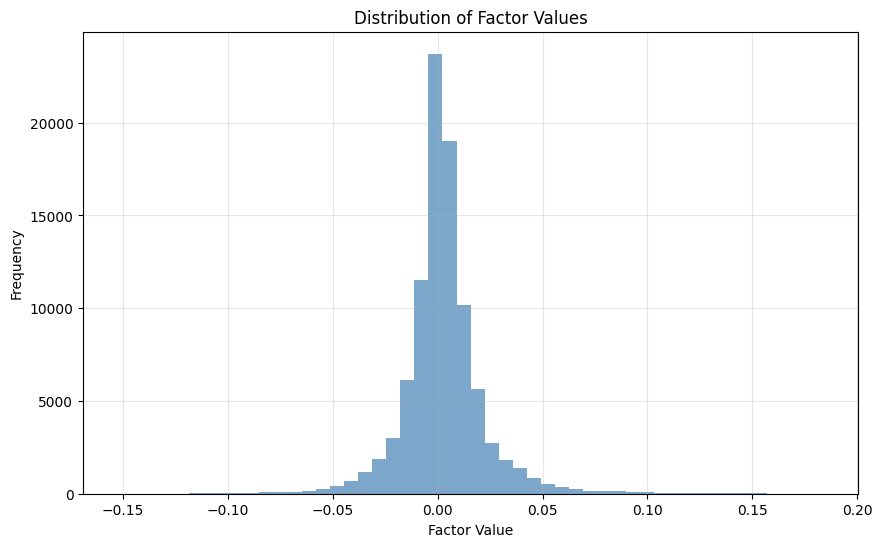

In [47]:
import matplotlib.pyplot as plt

# 绘制factor的分布图
plt.figure(figsize=(10, 6))
plt.hist(data['factor'].to_numpy(), bins=50, color='steelblue', alpha=0.7)
plt.title('Distribution of Factor Values')
plt.xlabel('Factor Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [48]:
data = data.with_columns(
    pl.col("factor").alias("pos")
)

In [49]:
# 计算pos(仓位 或 因子值和label的ic)
df_pd = data.to_pandas()

# 计算总体IC
overall_ic = df_pd['pos'].corr(df_pd['label']) * 100

# 计算换手率
n_symbols = len(df_pd['symbol'].unique())
n_days = max(df_pd["d"].nunique(), 1)
mtvr = df_pd.groupby("symbol")["pos"].diff().abs().sum() / n_symbols / n_days

# 添加年份列
df_pd['year'] = pd.to_datetime(df_pd['open_time']).dt.year

# 计算年度IC
yearly_ic = df_pd.groupby('year')[['pos', 'label']].corr().unstack()['label']['pos'] * 100

print(f"all ic: {overall_ic:.4f}, mtvr: {mtvr:.6f}")
yearly_ic

all ic: 1.5965, mtvr: 0.039925


year
2023    3.539572
2024    1.224710
2025    0.673820
Name: pos, dtype: float64

In [50]:
# 第一步：计算单期边际收益
data = data.with_columns(
    (pl.col("pos") * pl.col("label1").over("symbol")).alias("margin_return")
)

data=data.fill_null(0)

# 第二步：计算累积边际收益
data = data.with_columns(
    pl.col("margin_return").cum_sum().over("symbol").alias("cumulative_return")
)

# 第三步：先创建 position_change 列（相当于您代码中的abs_diff）
data = data.with_columns(
    pl.col("pos").diff().abs().over("symbol").alias("position_change")
)

# 第四步：再使用 position_change 列计算 cumulative_turnover
data = data.with_columns(
    pl.col("position_change").cum_sum().over("symbol").alias("cumulative_turnover")
)

# 获取每个品种最后一行的数据（相当于您代码中的last()）
final_stats = data.group_by("symbol").agg(
    pl.col("cumulative_return").last().alias("ret"),
    pl.col("cumulative_turnover").last().alias("abs_diff")
)

# 计算ret/abs_diff（相当于您代码中的ret/abs_diff）
final_stats = final_stats.filter(pl.col("abs_diff") != 0)
final_stats = final_stats.with_columns(
    (pl.col("ret") / pl.col("abs_diff") * 10000).alias("ret_per_turnover")
)

# 按ret降序排序
sorted_stats = final_stats.sort("ret", descending=True)

# 计算ret/abs_diff的平均值
avg_ret_per_turnover = final_stats.select(pl.mean("ret_per_turnover")).item()

# 输出结果
print(f"平均每单位换手收益率（×10000）: {avg_ret_per_turnover}")

# 返回排序后的结果
sorted_stats

平均每单位换手收益率（×10000）: 25.60359394636047


symbol,ret,abs_diff,ret_per_turnover
str,f64,f64,f64
"""1000PEPEUSDT""",0.099052,38.68693,25.603594


In [51]:
# 每个品种每天的 margin_return 之和（当日实际收益）

data = data.with_columns(
    pl.col("d").alias("day")
)
data_perday = data.group_by(["day", "symbol"]).agg(
    pl.col("margin_return").sum().alias("daily_ret")
)

# 按 day 聚合：横截面等权平均
data_perday = data_perday.group_by("day").agg(
    pl.col("daily_ret").mean().alias("avg_ret")
)

data_perday = data_perday.sort("day")
data_perday

day,avg_ret
i32,f64
20230508,-0.003151
20230509,-0.010456
20230510,-0.001327
20230511,0.001345
20230512,0.002829
…,…
20251227,0.000118
20251228,0.000069
20251229,-0.000188


In [52]:
# 累计收益曲线
curve = data_perday.with_columns(
    pl.col("avg_ret").cum_sum().alias("cum_avg_ret")
)
curve

day,avg_ret,cum_avg_ret
i32,f64,f64
20230508,-0.003151,-0.003151
20230509,-0.010456,-0.013608
20230510,-0.001327,-0.014934
20230511,0.001345,-0.013589
20230512,0.002829,-0.01076
…,…,…
20251227,0.000118,0.099233
20251228,0.000069,0.099302
20251229,-0.000188,0.099114


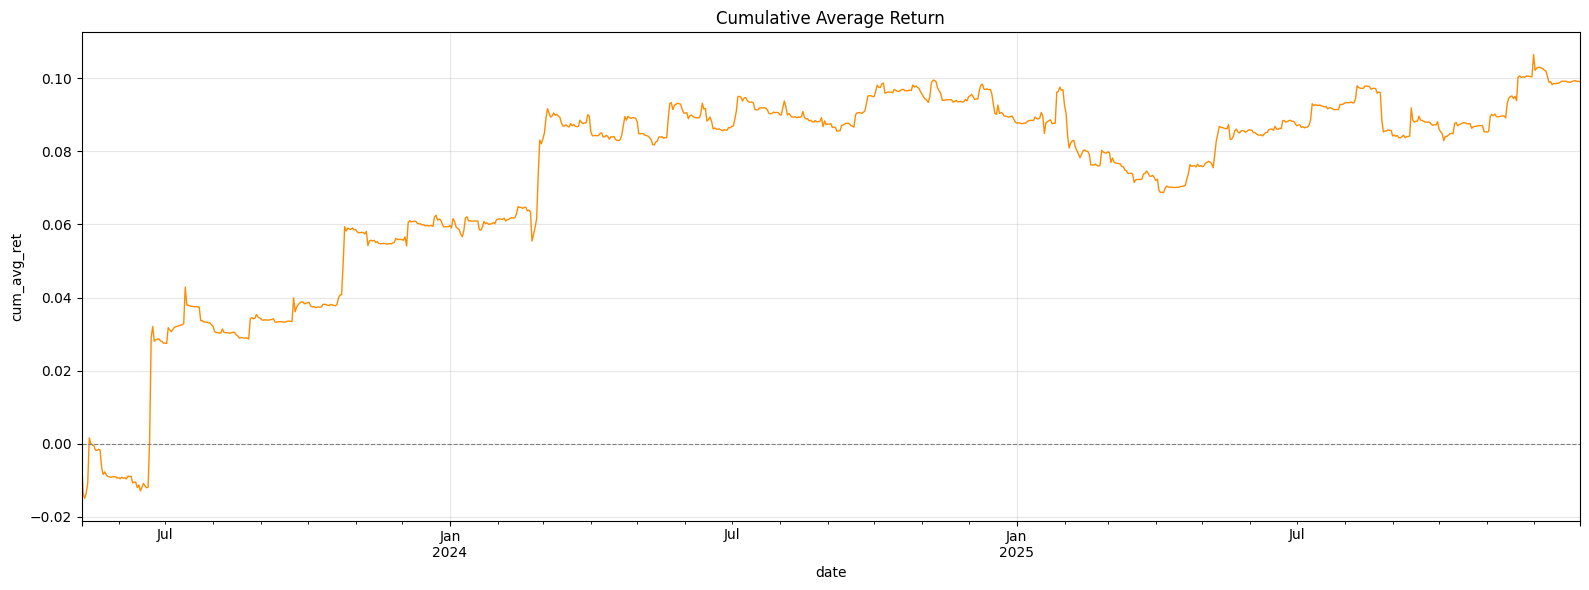

In [53]:
import matplotlib.pyplot as plt

curve_pd = curve.sort("day").to_pandas()
curve_pd["date"] = pd.to_datetime(curve_pd["day"].astype(str), format="%Y%m%d")
curve_pd = curve_pd.set_index("date")

fig, ax = plt.subplots(figsize=(16, 6))
curve_pd["cum_avg_ret"].plot(ax=ax, color="darkorange", linewidth=1)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("date")
ax.set_ylabel("cum_avg_ret")
ax.set_title("Cumulative Average Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()